In [46]:
#import libraries
import numpy as np
import pandas as pd
import yfinance as yf
import seaborn as sns
from scipy.optimize import minimize
import matplotlib.pyplot as plt

%matplotlib inline

In [47]:
#Portfolio construction

TICKERS = [
    # --- 1. US EQUITIES (Sector Diversification) ---
    "MSFT",   # Technology (Software & Cloud)
    "NVDA",   # Technology (Semiconductors)
    "LLY",    # Healthcare / Pharmaceuticals
    "JPM",    # Financials / Investment Banking
    "AMZN",   # Consumer Cyclical / E-Commerce
    "PG",     # Consumer Defensive / Consumer Goods
    "XOM",    # Energy / Oil & Gas
    "CAT",    # Industrials / Heavy Machinery
    "NEE",    # Utilities / Renewable Energy
    "AMT",    # Real Estate (REIT / Telecom Towers)

    # --- 2. INTERNATIONAL EQUITIES (Geographic Diversification) ---
    "ASML",   # Europe (Netherlands) - Semi-cap Equipment
    "NSRGY",  # Europe (Switzerland) - Consumer Goods (Nestlé)
    "SAP",    # Europe (Germany) - Enterprise Software
    "TM",     # Asia (Japan) - Automotive (Toyota)
    "SONY",   # Asia (Japan) - Electronics & Entertainment
    "TSM",    # Asia (Taiwan) - Semiconductor Foundry
    "BABA",   # Emerging Markets (China) - Tech & Retail
    "HDB",    # Emerging Markets (India) - Banking & Finance
    "VALE",   # Emerging Markets (Brazil) - Materials & Mining
    "RY",     # North America (Canada) - Banking (Royal Bank)

    # --- 3. FIXED INCOME (Bonds for De-correlation) ---
    "TLT",    # US Long-Term Treasury Bonds (20+ Years)
    "IEF",    # US Intermediate-Term Treasury Bonds (7-10 Years)
    "TIP",    # US Inflation-Protected Treasury Bonds (TIPS)
    "BNDX",   # Total International Bond ETF (Non-US Hedged)
    "EMB",    # Emerging Markets Sovereign Bond ETF

    # --- 4. ALTERNATIVE ASSETS & COMMODITIES (Alternative Allocation) ---
    "GLD",    # Gold Shares (Traditional Safe Haven)
    "SLV",    # Silver Shares (Precious & Industrial Metal)
    "USO",    # United States Oil Fund (WTI Crude Oil)
    "DBA",    # Invesco Agricultural Fund (Corn, Wheat, Soy, Coffee)
    #"IBIT"    # iShares Bitcoin Trust (Spot Bitcoin ETF)
]



START = "2016-01-01"
END = "2026-01-01"
RF = 0.045  # Risk-free rate
PORTFOLIO_VALUE = 1_000_000  # Portfolio value
n = len(TICKERS)  # Number of tickers

#Data collection

df = yf.download(TICKERS, start=START, end=END, auto_adjust = True)['Close']
df.dropna(how='all', inplace=True)
df.ffill(inplace=True)  # forward-fill sporadic NaNs
df.dropna(inplace=True)

returns = df.pct_change().dropna()
print(f"{len(returns)} trading days of returns data collected for {n} assets from {START} to {END}.")

df.head()

[*********************100%***********************]  29 of 29 completed

2513 trading days of returns data collected for 29 assets from 2016-01-01 to 2026-01-01.


Ticker,AMT,AMZN,ASML,BABA,BNDX,CAT,DBA,EMB,GLD,HDB,...,SAP,SLV,SONY,TIP,TLT,TM,TSM,USO,VALE,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2016-01-04,74.226456,31.849501,78.675888,72.169319,38.889175,52.989952,17.544298,63.905025,102.889999,13.561675,...,64.865387,13.19,4.663506,80.672951,90.649796,92.703476,16.926704,87.839996,1.555712,49.319614
2016-01-05,75.692558,31.689501,77.882812,73.994949,38.867153,52.436577,17.432550,64.074356,103.180000,13.706669,...,64.722443,13.31,4.803054,80.621681,90.284073,92.459251,16.819431,85.279999,1.550789,49.739861
2016-01-06,75.423920,31.632500,76.251610,72.771591,39.013950,51.610439,17.312208,64.068314,104.669998,13.727060,...,65.294243,13.36,4.456071,80.878075,91.500656,90.352699,16.352011,80.879997,1.432634,49.325981
2016-01-07,73.543312,30.396999,74.341049,68.433327,38.955231,49.833462,17.243439,63.765965,106.150002,13.335117,...,64.924240,13.62,4.388184,80.812210,91.664902,88.207970,16.168110,79.199997,1.334171,48.536457
2016-01-08,72.330521,30.352501,72.349342,66.626518,38.947880,49.326862,17.303612,63.711479,105.680000,13.251291,...,64.663582,13.30,4.337269,80.878075,92.075386,86.292236,15.945892,78.400002,1.280016,47.555943


In [48]:
#Performance metrics
mean_returns = returns.mean()*252  # Annualized mean returns
volatility = returns.std()*np.sqrt(252)  # Annualized volatility
cov_matrix = returns.cov()*252  # Annualized covariance matrix

risk_df = pd.DataFrame({
    'Ann. Return' : mean_returns,
    'Ann. Volatility' : volatility,
    'Sharpe Ratio' : (mean_returns - RF) / volatility 
}).round(4)

print("Individual stock performance metrics:\n")
print(risk_df.to_string())

Individual stock performance metrics:

        Ann. Return  Ann. Volatility  Sharpe Ratio
Ticker                                            
AMT          0.1179           0.2591        0.2815
AMZN         0.2523           0.3280        0.6322
ASML         0.3328           0.3770        0.7634
BABA         0.1611           0.4304        0.2697
BNDX         0.0212           0.0403       -0.5904
CAT          0.2846           0.3038        0.7887
DBA          0.0462           0.1316        0.0094
EMB          0.0435           0.0994       -0.0152
GLD          0.1462           0.1480        0.6839
HDB          0.1410           0.2879        0.3336
IEF          0.0144           0.0664       -0.4607
JPM          0.2271           0.2758        0.6604
LLY          0.3173           0.2943        0.9252
MSFT         0.2676           0.2676        0.8318
NEE          0.1710           0.2518        0.5004
NSRGY        0.0722           0.1823        0.1494
NVDA         0.6719           0.4989       

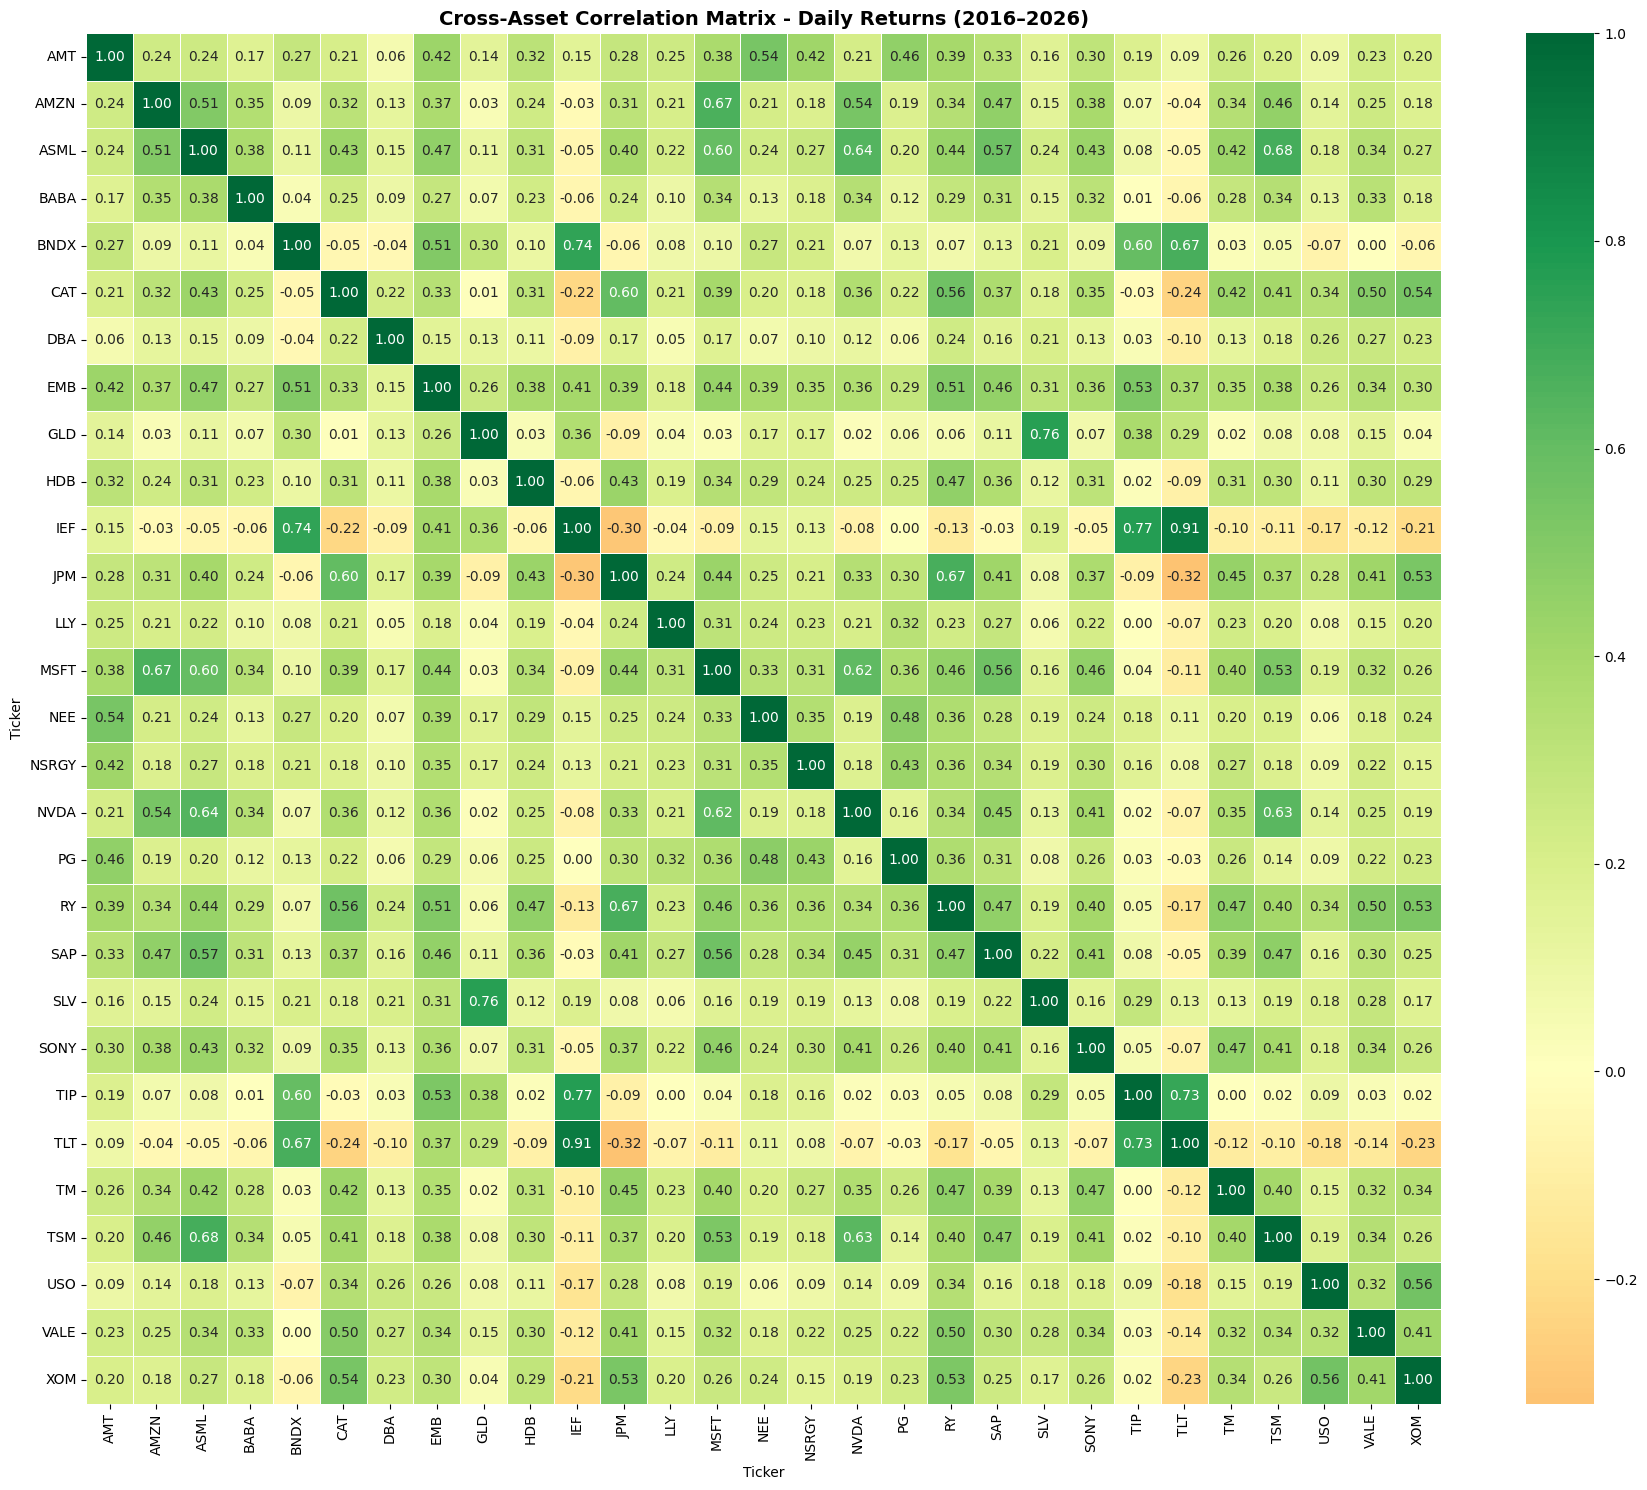

In [49]:
#Correlation heatmap
fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(returns.corr(), annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, ax=ax, linewidths=0.5)

ax.set_title('Cross-Asset Correlation Matrix - Daily Returns (2016–2026)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [50]:
#We create an equal weight portfolio

weights_eq = np.array([1/n]*n)  # Equal weights for each asset
port_ret_eq = np.sum(returns.mean() * 252 * weights_eq)
port_vol_eq = np.sqrt(np.dot(weights_eq.T, np.dot(cov_matrix, weights_eq)))
sharpe_eq = (port_ret_eq - RF) / port_vol_eq

print(f"Portfolio Performance Metrics:\n")

print("="*45)
print(f" {'':20}{'Equal Weight Portfolio':>20}")
print(f"{'Expected Return': <20} {port_ret_eq:10.2%}")   
print(f"{'Volatility': <20} {port_vol_eq:10.2%}")
print(f"{'Sharpe Ratio': <20} {sharpe_eq:.2f}")
print("="*45)

Portfolio Performance Metrics:

                     Equal Weight Portfolio
Expected Return          17.70%
Volatility               13.81%
Sharpe Ratio         0.96


In [51]:
#Portfolio Optimization using scipy
#helper functions
def portfolio_return(weights):
    return np.sum(returns.mean() * 252 * weights)

def portfolio_volatility(weights):
    return np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

def neg_sharpe(weights):
    return -(portfolio_return(weights) - RF) / portfolio_volatility(weights)

#constraints and bounds
constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
bounds = tuple((0, 1) for _ in range(n))
init_guess = np.repeat(1/n, n)

#optimize for max Sharpe ratio
opt_sharpe = minimize(neg_sharpe, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)

w_optimal = opt_sharpe.x
returns_optimal = portfolio_return(w_optimal)
volatility_optimal = portfolio_volatility(w_optimal)
sharpe_optimal = (returns_optimal - RF) / volatility_optimal

#optimize for minimum volatility
opt_min_vol = minimize(portfolio_volatility, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)

w_min_volatility = opt_min_vol.x
returns_min_volatility = portfolio_return(w_min_volatility)
volatility_min_volatility = portfolio_volatility(w_min_volatility)
sharpe_min_volatility = (returns_min_volatility - RF) / volatility_min_volatility

print(f"Optimization complete using SLSQP.\n")
print(f"Max Sharpe Ratio Portfolio:")
print(f"  Expected Return: {returns_optimal:10.2%}")
print(f"  Volatility: {volatility_optimal:10.2%}")
print(f"  Sharpe Ratio: {sharpe_optimal:.2f}")


print(f"\nMinimum Volatility Portfolio:")
print(f"  Expected Return: {returns_min_volatility:10.2%}")
print(f"  Volatility: {volatility_min_volatility:10.2%}")   
print(f"  Sharpe Ratio: {sharpe_min_volatility:.2f}")

Optimization complete using SLSQP.

Max Sharpe Ratio Portfolio:
  Expected Return:     30.74%
  Volatility:     16.53%
  Sharpe Ratio: 1.59

Minimum Volatility Portfolio:
  Expected Return:      2.82%
  Volatility:      3.74%
  Sharpe Ratio: -0.45


In [52]:
# ----------------------------------------------- Daily portfolio returns  ---------------------------------------------------

#Max Sharpe Portfolio
port_returns = (returns * w_optimal).sum(axis=1)
var_results  = {}

print("  VALUE AT RISK & CVaR - Max Sharpe Portfolio")
print(f"    Portfolio value : €{PORTFOLIO_VALUE:,}\n")

for cl in [0.95, 0.99]:
    alpha    = 1 - cl
    var_pct  = np.percentile(port_returns, alpha * 100)
    cvar_pct = port_returns[port_returns <= var_pct].mean()
    var_results[cl] = {'var_pct': var_pct, 'cvar_pct': cvar_pct}

    print(f"   Confidence level : {cl:.0%}")
    print(f"   Historical VaR   : {var_pct:.2%}  (= €{var_pct * PORTFOLIO_VALUE:,.0f})")
    print(f"   Historical CVaR  : {cvar_pct:.2%}  (= €{cvar_pct * PORTFOLIO_VALUE:,.0f})")
    print()

#Minimum Volatility Portfolio
port_returns_min_vol = (returns * w_min_volatility).sum(axis=1) 
var_results_min_vol  = {}

print("  VALUE AT RISK & CVaR - Minimum Volatility Portfolio")
print(f"    Portfolio value : €{PORTFOLIO_VALUE:,}\n")

for cl in [0.95, 0.99]:
    alpha    = 1 - cl
    var_pct  = np.percentile(port_returns_min_vol, alpha * 100)
    cvar_pct = port_returns_min_vol[port_returns_min_vol <= var_pct].mean()
    var_results_min_vol[cl] = {'var_pct': var_pct, 'cvar_pct': cvar_pct}

    print(f"   Confidence level : {cl:.0%}")
    print(f"   Historical VaR   : {var_pct:.2%}  (= €{var_pct * PORTFOLIO_VALUE:,.0f})")
    print(f"   Historical CVaR  : {cvar_pct:.2%}  (= €{cvar_pct * PORTFOLIO_VALUE:,.0f})")
    print()

# Equal-Weight Portfolio
port_returns_eq = (returns * weights_eq).sum(axis=1)
var_results_eq = {}

print("  VALUE AT RISK & CVaR - Equal-Weight Portfolio")
print(f"    Portfolio value : €{PORTFOLIO_VALUE:,}\n")

for cl in [0.95, 0.99]:
    alpha    = 1 - cl
    var_pct  = np.percentile(port_returns_eq, alpha * 100)
    cvar_pct = port_returns_eq[port_returns_eq <= var_pct].mean()
    var_results_eq[cl] = {'var_pct': var_pct, 'cvar_pct': cvar_pct}

    print(f"   Confidence level : {cl:.0%}")
    print(f"   Historical VaR   : {var_pct:.2%}  (= €{var_pct * PORTFOLIO_VALUE:,.0f})")
    print(f"   Historical CVaR  : {cvar_pct:.2%}  (= €{cvar_pct * PORTFOLIO_VALUE:,.0f})")
    print()

  VALUE AT RISK & CVaR - Max Sharpe Portfolio
    Portfolio value : €1,000,000

   Confidence level : 95%
   Historical VaR   : -1.50%  (= €-14,971)
   Historical CVaR  : -2.24%  (= €-22,363)

   Confidence level : 99%
   Historical VaR   : -2.71%  (= €-27,084)
   Historical CVaR  : -3.59%  (= €-35,856)

  VALUE AT RISK & CVaR - Minimum Volatility Portfolio
    Portfolio value : €1,000,000

   Confidence level : 95%
   Historical VaR   : -0.37%  (= €-3,664)
   Historical CVaR  : -0.54%  (= €-5,415)

   Confidence level : 99%
   Historical VaR   : -0.60%  (= €-5,988)
   Historical CVaR  : -0.89%  (= €-8,907)

  VALUE AT RISK & CVaR - Equal-Weight Portfolio
    Portfolio value : €1,000,000

   Confidence level : 95%
   Historical VaR   : -1.29%  (= €-12,884)
   Historical CVaR  : -1.99%  (= €-19,896)

   Confidence level : 99%
   Historical VaR   : -2.31%  (= €-23,064)
   Historical CVaR  : -3.45%  (= €-34,546)



[*********************100%***********************]  1 of 1 completed


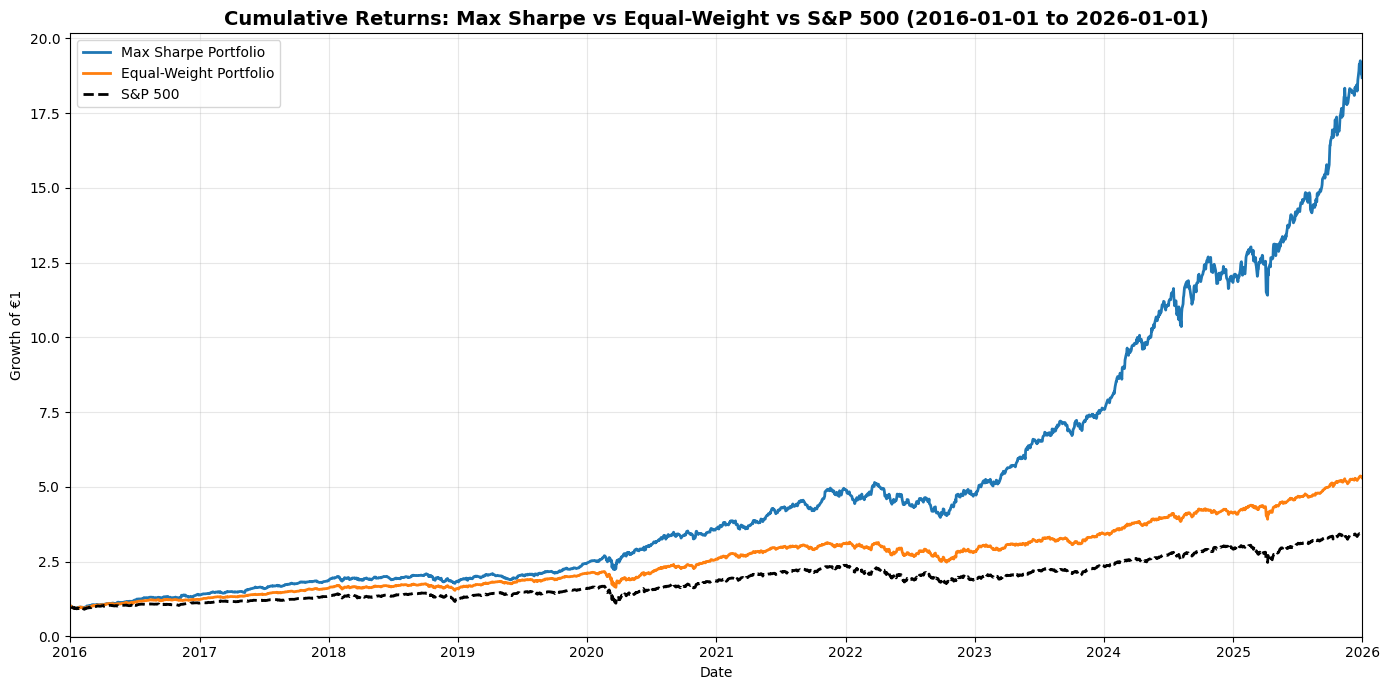

In [53]:
# visualization of the cumulative returns of the Max Sharpe, Equal-Weight  and the SP500 portfolios

#S&P 500 benchmark data, over the full START-END window
sp500 = yf.download("^GSPC", start=START, end=END, auto_adjust=True)['Close'].squeeze()
sp500_returns = sp500.pct_change().dropna()
sp500_returns = sp500_returns.reindex(returns.index).dropna()

#cumulative growth of €1
cum_max_sharpe = (1 + port_returns).cumprod()
cum_eq         = (1 + port_returns_eq).cumprod()
cum_sp500      = (1 + sp500_returns).cumprod()

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(cum_max_sharpe.index, cum_max_sharpe, label='Max Sharpe Portfolio', linewidth=2)
ax.plot(cum_eq.index, cum_eq, label='Equal-Weight Portfolio', linewidth=2)
ax.plot(cum_sp500.index, cum_sp500, label='S&P 500', linewidth=2, linestyle='--', color='black')

ax.set_title(f'Cumulative Returns: Max Sharpe vs Equal-Weight vs S&P 500 ({START} to {END})',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Growth of €1')
ax.set_xlabel('Date')
ax.set_xlim(pd.to_datetime(START), pd.to_datetime(END))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ----------------------------------------------- Cumulative return over the full period ---------------------------------------------------

cum_return_max_sharpe = cum_max_sharpe.iloc[-1] - 1
cum_return_eq         = cum_eq.iloc[-1] - 1
cum_return_sp500      = cum_sp500.iloc[-1] - 1

summary_df['Cumulative Return'] = [
    cum_return_max_sharpe,
    np.nan,  
    cum_return_eq,
]

print("CUMULATIVE RETURN — full period ({} to {})".format(START, END))
print(f"  Max Sharpe Portfolio   : {cum_return_max_sharpe:.2%}")
print(f"  Equal-Weight Portfolio : {cum_return_eq:.2%}")
print(f"  S&P 500 (benchmark)    : {cum_return_sp500:.2%}")

CUMULATIVE RETURN — full period (2016-01-01 to 2026-01-01)
  Max Sharpe Portfolio   : 1768.25%
  Equal-Weight Portfolio : 430.97%
  S&P 500 (benchmark)    : 240.12%


In [62]:
#summary of the results
top_holdings = pd.Series(w_optimal, index=TICKERS).sort_values(ascending=False)
print(f"\nTop 5 holdings - Max Sharpe Portfolio:\n")
print(top_holdings.head(5).apply(lambda x: f"{x:.2%}").to_string())

# --- S&P 500 benchmark metrics ---
sp500_return_ann = sp500_returns.mean() * 252
sp500_vol_ann    = sp500_returns.std() * np.sqrt(252)
sp500_sharpe     = (sp500_return_ann - RF) / sp500_vol_ann

sp500_var_results = {}
for cl in [0.95, 0.99]:
    alpha   = 1 - cl
    var_pct = np.percentile(sp500_returns, alpha * 100)
    cvar_pct = sp500_returns[sp500_returns <= var_pct].mean()
    sp500_var_results[cl] = {'var_pct': var_pct, 'cvar_pct': cvar_pct}

# Cumulative returns over the full period
cum_min_vol = (1 + port_returns_min_vol).cumprod()

cum_return_max_sharpe = cum_max_sharpe.iloc[-1] - 1
cum_return_min_vol    = cum_min_vol.iloc[-1] - 1
cum_return_eq         = cum_eq.iloc[-1] - 1
cum_return_sp500      = cum_sp500.iloc[-1] - 1

summary_df = pd.DataFrame({
    'Max Sharpe' : {
        'Expected Return'    : returns_optimal,
        'Volatility'         : volatility_optimal,
        'Sharpe Ratio'       : sharpe_optimal,
        'VaR (95%)'          : var_results[0.95]['var_pct'],
        'CVaR (95%)'         : var_results[0.95]['cvar_pct'],
        'Cumulative Return'  : cum_return_max_sharpe,
    },
    'Equal Weight' : {
        'Expected Return'    : port_ret_eq,
        'Volatility'         : port_vol_eq,
        'Sharpe Ratio'       : sharpe_eq,
        'VaR (95%)'          : var_results_eq[0.95]['var_pct'],
        'CVaR (95%)'         : var_results_eq[0.95]['cvar_pct'],
        'Cumulative Return'  : cum_return_eq,
    },
    'S&P 500' : {
        'Expected Return'    : sp500_return_ann,
        'Volatility'         : sp500_vol_ann,
        'Sharpe Ratio'       : sp500_sharpe,
        'VaR (95%)'          : sp500_var_results[0.95]['var_pct'],
        'CVaR (95%)'         : sp500_var_results[0.95]['cvar_pct'],
        'Cumulative Return'  : cum_return_sp500,
    },
    
}).T

print("\n PORTFOLIO SUMMARY\n")
print(summary_df.to_string(formatters={
    'Expected Return'   : '{:.2%}'.format,
    'Volatility'        : '{:.2%}'.format,
    'Sharpe Ratio'      : '{:.2f}'.format,
    'VaR (95%)'         : '{:.2%}'.format,
    'CVaR (95%)'        : '{:.2%}'.format,
    'Cumulative Return' : '{:.2%}'.format,
}))


Top 5 holdings - Max Sharpe Portfolio:

NEE      45.49%
SAP      21.98%
BABA     20.79%
PG        8.25%
NSRGY     3.46%

 PORTFOLIO SUMMARY

             Expected Return Volatility Sharpe Ratio VaR (95%) CVaR (95%) Cumulative Return
Max Sharpe            30.74%     16.53%         1.59    -1.50%     -2.24%          1768.25%
Equal Weight          17.70%     13.81%         0.96    -1.29%     -1.99%           430.97%
S&P 500               13.93%     18.13%         0.52    -1.70%     -2.78%           240.12%


## Limitations & Future Improvements

### Current Limitations

**Methodology**
- **In-sample optimization (look-ahead bias)**: weights are optimized once over the entire 2016–2026 window using the full history, including data that would not have been available at the time of investing. Real-world performance would be materially worse.
- **Static allocation**: no rebalancing over the period — weights are fixed at t=0 and never adjusted, which is unrealistic for any live strategy.
- **Mean-variance framework only**: relies solely on Markowitz (mean/variance), which assumes returns are normally distributed and ignores skewness, fat tails, and regime changes — all well documented in real markets.
- **Arithmetic mean returns**: `returns.mean()*252` overstates expected return relative to what would actually be realized (CAGR), especially for volatile assets.
- **No transaction costs, slippage, or taxes**: the optimizer assumes frictionless trading, which inflates apparent performance.
- **No liquidity or capacity constraints**: assumes any position size is executable at the observed price, unrealistic for less liquid tickers (e.g. HDB, VALE, BABA).

**Data**
- **Survivorship bias**: only currently-listed, well-known large caps are used — no delisted or failed companies are included, which biases historical returns upward.
- **Currency risk not modeled explicitly**: international tickers (ASML, SAP, TSM, HDB, etc.) are priced in USD via ADR/local listing, but underlying currency exposure and hedging costs are not isolated.
- **Fixed universe of 29 tickers**: hand-picked for sector/geographic diversification, not derived from a systematic screening process (factor exposure, liquidity, market cap thresholds).
- **Single fixed risk-free rate**: `RF = 0.045` is a constant across 10 years, when the actual risk-free rate varied significantly (near-zero in 2015–2021, higher post-2022).

**Risk Modeling**
- **Historical VaR/CVaR only**: based purely on empirical percentiles of past returns, not parametric or Monte Carlo methods, and doesn't account for tail risk beyond the observed sample.
- **Covariance matrix instability**: a single covariance matrix computed over 10 years assumes stable correlations, while correlations are known to shift substantially in crises (see 2020, 2022).

### Possible Improvements

**Methodology**
- Implement a **walk-forward / rolling window backtest**: re-optimize periodically (e.g. quarterly/annually) using only data available up to that point, then evaluate out-of-sample performance.
- Add a **rebalancing schedule** (e.g. calendar-based or threshold-based) with associated transaction costs.
- Extend beyond mean-variance to **robust optimization** (e.g. Black-Litterman to incorporate views, or Hierarchical Risk Parity to avoid unstable covariance-matrix inversion).
- Explore **risk-parity** and **maximum diversification** portfolios as additional benchmarks alongside Max Sharpe / Min Volatility.
- Use **CAGR / geometric returns** instead of arithmetic means for reporting expected performance, while keeping arithmetic returns for the optimization step itself (standard convention).

**Data**
- Expand or systematize the **ticker universe** via factor screens (market cap, sector, liquidity) rather than manual selection, and periodically refresh it.
- Model **currency exposure and FX-hedged vs unhedged returns** separately for international holdings.
- Use a **time-varying risk-free rate** (e.g. 3-month T-bill yield history) instead of a constant.
- Address the **track record length mismatch** across tickers (e.g. TSM, HDB, ASML may have shorter or differently-adjusted histories) with more careful alignment or an explicit minimum-history filter.

**Risk Modeling**
- Add **Monte Carlo simulation** for VaR/CVaR to capture tail scenarios not present in the historical sample.
- Use **shrinkage estimators** (e.g. Ledoit-Wolf) for the covariance matrix to reduce estimation noise, especially with 29 assets and a finite sample size.
- Add **stress testing** against specific historical crisis periods (2020 COVID crash, 2022 rate-hike selloff) rather than relying only on full-period statistics.
- Incorporate **factor exposure analysis** (e.g. exposure to market, size, value, momentum factors) to understand *why* the portfolio behaves the way it does, not just *how*.

**Engineering / Productionization**
- Wrap the pipeline into **reusable functions/classes** (data loader, optimizer, risk engine, reporting) instead of a linear notebook script.
- Add **unit tests** for the optimization and risk functions.
- Cache downloaded price data locally to avoid repeated API calls and to allow offline reproducibility.
- Add a **config file** (YAML/JSON) for parameters (tickers, dates, risk-free rate, constraints) instead of hardcoding them in the notebook.
- Build a lightweight **dashboard** (e.g. Streamlit) to interactively explore different constraint sets, universes, and time windows.